In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'
TEST_YEAR = '2018'

base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(39192, 91)


In [2]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL51,EL514,κατω νευροκοπιου,2018,1,23.65882,41.33542,0.118628,0.225708,0.002172,-0.225708,0.166330,0.160403,-0.098270,-0.160403,0.065668,0.060549,0.100355,0.060549,2.257097,4.397097,6.644286,9.922258,21.524000,-1.473871,-0.402903,-0.282143,2.237097,7.890000,0.391613,1.997097,3.181071,6.079677,14.707000,-8.81,8.27,4.038921,19.500314,22.209316,84.974539,40.42494,10.041667,21.250000,33.730159,1073.113214,32.0,-31.0,63.0,4.500000,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
1,1,EL51,EL514,κατω νευροκοπιου,2018,1,23.65882,41.35339,0.283504,0.122199,-0.283933,-0.122199,0.282141,0.114074,-0.288418,-0.114074,0.043312,0.061901,0.028893,0.061901,4.482258,6.967419,10.285714,12.944194,25.694667,-1.922258,-1.180323,-1.155000,-1.677742,7.321333,1.280000,2.893548,4.565357,5.633226,16.508000,-9.69,10.17,4.038921,19.500314,22.209316,84.974539,40.42494,12.875000,25.083333,44.005848,996.613584,39.0,-18.0,57.0,6.000000,19.000000,23.666667,-0.166667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,299.0,31,30,30,10,10,1,6,6,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.0,7.312587,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
2,2,EL51,EL514,κατω νευροκοπιου,2018,1,23.65882,41.37135,0.141255,0.333712,-0.190819,-0.333712,0.236240,0.283869,-0.239333,-0.283869,0.089209,0.135913,0.083265,0.135913,5.329355,3.763548,6.875714,12.429355,24.959333,-2.328065,-1.377097,-1.157143,0.951935,6.224667,1.500645,1.193226,2.859286,6.690645,15.592000,-9.69,11.81,4.038921,19.500314,22.209316,84.974539,40.42494,11.750000,28.166667,40.821256,1065.257118,38.0,-31.0,69.0,6.166667,17.833333,22.500000,-2.333333,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,299.0,31,30,30,10,10,1,6,6,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.0,1.647387,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
3,3,EL51,EL514,κατω νευροκοπιου,2018,1,23.68241,41.33542,0.232764,0.134358,-0.184290,-0.134358,0.214182,0.112510,-0.150714,-0.112510,0.038901,0.046435,0.057942,0.046435,2.578387,4.053226,7.067143,9.647419,22.097333,-1.191290,-1.139677,-0.549286,1.900968,7.734000,0.693548,1.456774,3.258929,5.774194,14.915667,-8.79,7.37,4.038921,19.500314,22.209316,84.974539,40.42494,10.083333,21.000000,34.426230,1055.684468,31.0,-30.0,61.0,4.166667,16.500000,20.833333,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.0,9.000000,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
4,4,EL51,EL514,κατω νευροκοπιου,2018,1,23.68241,41.35339,0.238351,0.082223,-0.247567,-0.082223,0.280254,0.071385,-0.273187,-0.071385,0.041376,0.048972,0.041971,0.048972,5.542258,8.104194,11.402143,12.159677,27.073333,-2.281613,-1

In [4]:
len(data_train.cell_code.unique())

4260

In [5]:
len(data_test.cell_number.unique())

3266

In [6]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
data_train.cases.sum()

1364

In [8]:
# data_test.cases.sum()

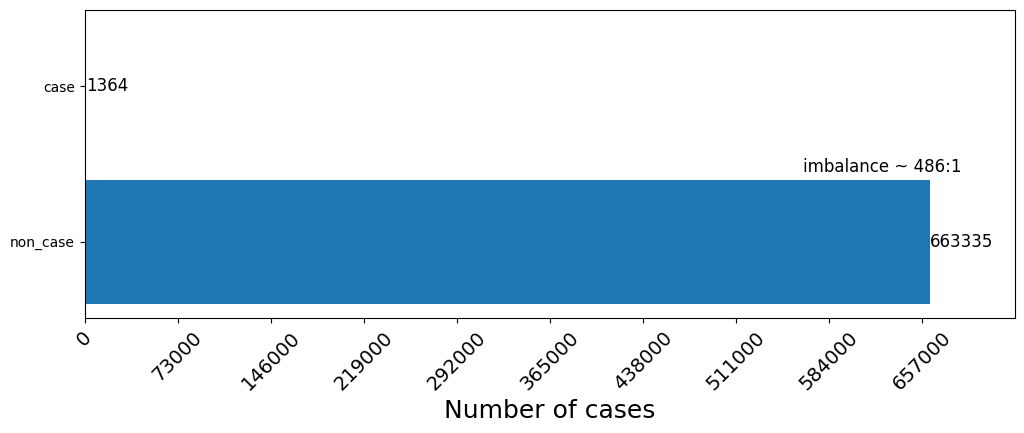

In [9]:
plot_imbalance(data_train, target_column='cases')

In [10]:
# plot_imbalance(data_test, target_column='cases')

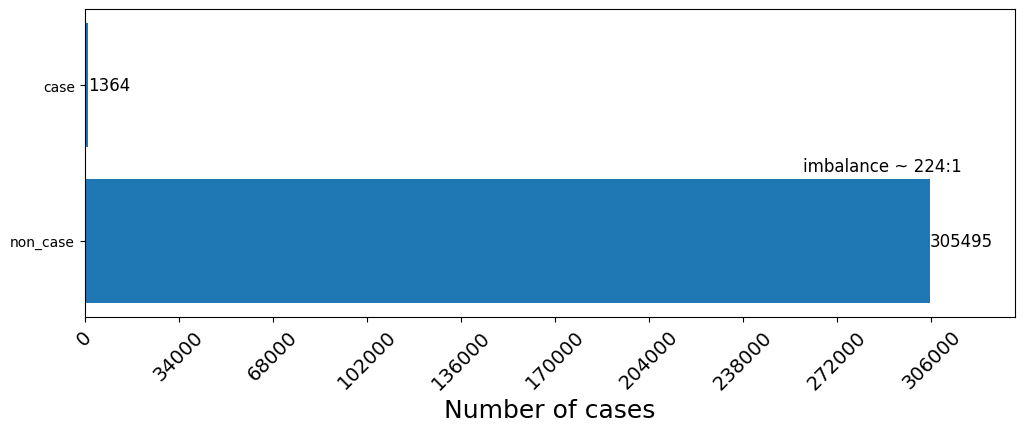

In [11]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [12]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

# plot_imbalance(data_test, target_column='cases')

In [13]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

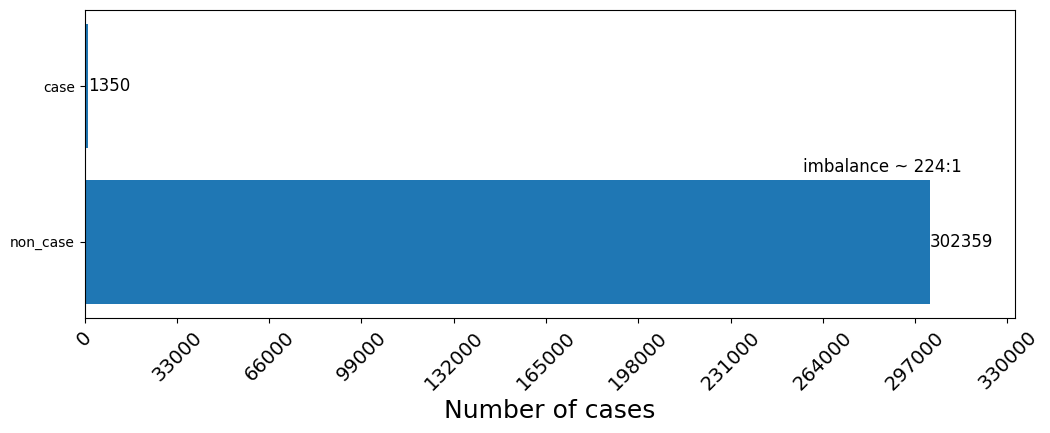

In [14]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [15]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

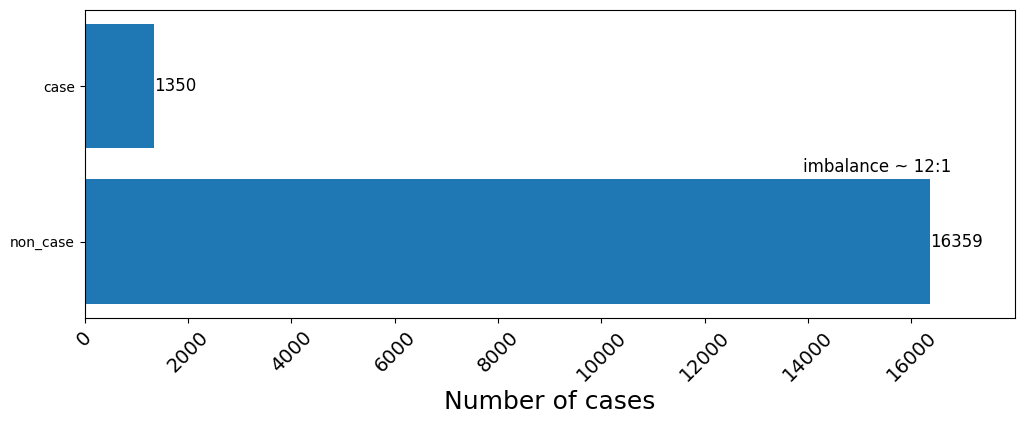

In [16]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [17]:
data_train.shape

(17570, 94)

In [18]:
data_train.cases.sum()

1350

In [19]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1390,262,1652,5.31%
1,2011,1352,100,1452,13.52%
2,2012,1361,157,1518,8.67%
3,2013,1407,85,1492,16.55%
4,2014,1314,15,1329,87.60%
5,2015,1407,0,1407,inf%
6,2016,1390,0,1390,inf%
7,2017,1321,42,1363,31.45%
8,2018,1173,282,1455,4.16%
9,2019,1408,218,1626,6.46%


In [20]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [21]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 12.12
Weight: 12.12


In [22]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [23]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL51,EL514,κατω νευροκοπιου,2018,5,23.65882,41.33542,0.441659,0.045443,-0.393383,-0.045443,0.419822,0.050334,-0.369687,-0.050334,0.038137,0.032878,0.047098,0.032878,21.524000,4.397097,6.644286,9.922258,21.524000,7.890000,-0.402903,-0.282143,2.237097,7.890000,14.707000,1.997097,3.181071,6.079677,14.707000,2.35,24.75,0.982650,19.899081,21.815958,29.479512,588.103224,10.041667,21.250000,33.730159,1073.113214,32.0,-31.0,63.0,4.500000,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2,0.500000,-0.866025
1,1,EL51,EL514,κατω νευροκοπιου,2018,5,23.65882,41.35339,0.385437,-0.036835,-0.377349,0.036835,0.374427,-0.051304,-0.366977,0.051304,0.030867,0.036896,0.020301,0.036896,25.694667,6.967419,10.285714,12.944194,25.694667,7.321333,-1.180323,-1.155000,-1.677742,7.321333,16.508000,2.893548,4.565357,5.633226,16.508000,1.87,30.51,0.982650,19.899081,21.815958,29.479512,588.103224,12.875000,25.083333,44.005848,996.613584,39.0,-18.0,57.0,6.000000,19.000000,23.666667,-0.166667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,299.0,31,30,30,10,10,1,6,6,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.0,7.312587,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2,0.500000,-0.866025
2,2,EL51,EL514,κατω νευροκοπιου,2018,5,23.65882,41.37135,0.251901,-0.097180,-0.287030,0.097180,0.323604,0.047440,-0.314057,-0.047440,0.101625,0.188633,0.071342,0.188633,24.959333,3.763548,6.875714,12.429355,24.959333,6.224667,-1.377097,-1.157143,0.951935,6.224667,15.592000,1.193226,2.859286,6.690645,15.592000,0.99,30.23,0.982650,19.899081,21.815958,29.479512,588.103224,11.750000,28.166667,40.821256,1065.257118,38.0,-31.0,69.0,6.166667,17.833333,22.500000,-2.333333,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,299.0,31,30,30,10,10,1,6,6,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.0,1.647387,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2,0.500000,-0.866025
3,3,EL51,EL514,κατω νευροκοπιου,2018,5,23.68241,41.33542,0.399346,-0.006277,-0.369304,0.006277,0.413917,0.006805,-0.366416,-0.006805,0.025010,0.021470,0.021668,0.021470,22.097333,4.053226,7.067143,9.647419,22.097333,7.734000,-1.139677,-0.549286,1.900968,7.734000,14.915667,1.456774,3.258929,5.774194,14.915667,2.31,25.57,0.982650,19.899081,21.815958,29.479512,588.103224,10.083333,21.000000,34.426230,1055.684468,31.0,-30.0,61.0,4.166667,16.500000,20.833333,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.0,9.000000,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2,0.500000,-0.866025
4,4,EL51,EL514,κατω νευροκοπιου,2018,5,23.68241,41.35339,0.386582,-0.052921,-0.376235,0.052921,0.376157,-0.016662,-0.35251

### Results 2018 ###

In [24]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [25]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1779,1779,EL51,EL513,κομοτηνης,2018,5,25.23934,40.95812,0.018977
1710,1710,EL51,EL513,ιασμου,2018,5,25.14498,41.04795,0.017717
459,459,EL51,EL515,παγγαιου,2018,5,24.17780,40.99405,0.010235
417,417,EL51,EL515,παγγαιου,2018,5,24.15421,40.99405,0.010104
1743,1743,EL51,EL513,κομοτηνης,2018,5,25.19216,40.95812,0.009395


In [31]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1827,1827,EL51,EL513,κομοτηνης,2018,6,25.31011,40.97609,0.134880
1812,1812,EL51,EL513,κομοτηνης,2018,6,25.28652,40.97609,0.113072
1979,1979,EL51,EL513,μαρωνειας σαπων,2018,6,25.49883,41.01202,0.087325
1896,1896,EL51,EL513,μαρωνειας σαπων,2018,6,25.40447,40.99405,0.084154
1768,1768,EL51,EL513,ιασμου,2018,6,25.21575,41.06592,0.079411


In [32]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1827,1827,EL51,EL513,κομοτηνης,2018,7,25.31011,40.97609,0.774378
1749,1749,EL51,EL513,ιασμου,2018,7,25.19216,41.06592,0.748100
1624,1624,EL51,EL512,αβδηρων,2018,7,25.02703,41.10185,0.745425
1876,1876,EL51,EL513,μαρωνειας σαπων,2018,7,25.38088,40.97609,0.737182
1802,1802,EL51,EL513,κομοτηνης,2018,7,25.26293,41.08389,0.733762


In [33]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1802,1802,EL51,EL513,κομοτηνης,2018,8,25.26293,41.08389,0.897073
1981,1981,EL51,EL513,μαρωνειας σαπων,2018,8,25.49883,41.04795,0.886712
2032,2032,EL51,EL513,μαρωνειας σαπων,2018,8,25.54601,41.02999,0.866039
1827,1827,EL51,EL513,κομοτηνης,2018,8,25.31011,40.97609,0.862664
1819,1819,EL51,EL513,κομοτηνης,2018,8,25.28652,41.10185,0.856807


In [34]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1827,1827,EL51,EL513,κομοτηνης,2018,9,25.31011,40.97609,0.916810
1834,1834,EL51,EL513,κομοτηνης,2018,9,25.31011,41.10185,0.877195
1625,1625,EL51,EL512,αβδηρων,2018,9,25.02703,41.11982,0.833579
1802,1802,EL51,EL513,κομοτηνης,2018,9,25.26293,41.08389,0.829153
1860,1860,EL51,EL513,κομοτηνης,2018,9,25.35729,40.99405,0.819350


In [35]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1819,1819,EL51,EL513,κομοτηνης,2018,10,25.28652,41.10185,0.360784
1768,1768,EL51,EL513,ιασμου,2018,10,25.21575,41.06592,0.280402
1662,1662,EL51,EL513,ιασμου,2018,10,25.07421,41.10185,0.263195
1802,1802,EL51,EL513,κομοτηνης,2018,10,25.26293,41.08389,0.262800
1730,1730,EL51,EL513,ιασμου,2018,10,25.16857,41.06592,0.247778


In [36]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
cm_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [37]:
cm_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL51,23.65882,41.33542,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,EL51,23.65882,41.35339,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,EL51,23.65882,41.37135,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,EL51,23.68241,41.33542,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,EL51,23.68241,41.35339,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."


In [38]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [39]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [40]:
greece_lakes.head()

,objectid,EU_CD,MS_CD,NAME,ALTNAME1,ALTNAME2,ALTNAME3,BASIN_CD,CHARACTER_,shape_area,shape_len,geometry
0,1,GR001100030020H,001100030020H,????? ???????,KERKINI LAKE,None,None,11,Insufficient Data,46088780.0,70604.0100,"POLYGON ((23.08306 41.19977, 23.08406 41.20032..."
1,2,GR001200030030N,001200030030N,????? ????????,ISMARIDA LAKE,None,None,12,Insufficient Data,1865103.9,5520.0850,"POLYGON ((25.30798 40.99044, 25.30862 40.99215..."
2,3,GR000800030010H,000800030010H,??????? ????? ??????,KARLAS RESERVOIR,None,None,08,Insufficient Data,34925588.0,29704.8950,"POLYGON ((22.78068 39.49602, 22.78083 39.49649..."
3,4,GR000800030020H,000800030020H,??????? ????? ????????,SMOKOVO RESERVOIR,None,None,08,Insufficient Data,9917521.0,57610.2000,"POLYGON ((22.04919 39.10001, 22.05059 39.10001..."
4,5,GR001300030020N,001300030020N,????? ??????,KOURNA LAKE,None,None,13,No Risk,561666.4,2849.8203,"POLYGON ((24.27341 35.33136, 24.27384 35.33312..."


In [41]:
cm_grid = cm_grid.to_crs(epsg=4326)
cm_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
cm_grid = cm_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {cm_grid.crs}')

greece_index CRS: EPSG:4326


In [42]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts2 CRS: EPSG:4326


In [43]:
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME'], inplace=True)

wrong_list = ['Σιντικής' ,'Σερρών', 'Εμμανουήλ Παππά', 'Νέας Ζίχνης', 'Αμφίπολης']

greece_lau1 = greece_lau1[~greece_lau1['NAME'].isin(wrong_list)].copy()
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lau1 CRS: EPSG:4326


In [44]:
greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_lakes CRS: EPSG:4326


In [45]:
cm_grid.head()

,cell_number,geometry
0,0,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."


In [46]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL51,"Aνατολική Μακεδονία, Θράκη","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [47]:
greece_lau1.head()

,NAME,geometry
0,Αβδήρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,Αλεξανδρούπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
2,Αρριανών,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
3,Διδυμοτείχου,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
4,Δοξάτου,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."


In [48]:
greece_lakes.head()

,name,area,length,geometry
0,ISMARIDA LAKE,1865103.9,5520.085,"POLYGON ((25.30862 40.99215, 25.30977 40.99238..."
1,LEFKOGION RESERVOIR,1091876.6,11878.964,"POLYGON ((23.90767 41.40275, 23.90769 41.40308..."
2,PLATANOBRISI RESERVOIR,3250727.5,40050.050,"POLYGON ((24.37308 41.36354, 24.37362 41.36409..."
3,THISAVROS RESERVOIR,6928690.5,34912.035,"POLYGON ((24.28272 41.31770, 24.28317 41.31766..."
4,GRATINI RESERVOIR,1434043.4,12178.949,"POLYGON ((25.51603 41.16096, 25.51670 41.16102..."


In [49]:
results_may = pd.merge(results_may, cm_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')

results_jun = pd.merge(results_jun, cm_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')

results_jul = pd.merge(results_jul, cm_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')

results_aug = pd.merge(results_aug, cm_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')

results_sep = pd.merge(results_sep, cm_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')

results_oct = pd.merge(results_oct, cm_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')

In [50]:
float_column = 'score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm

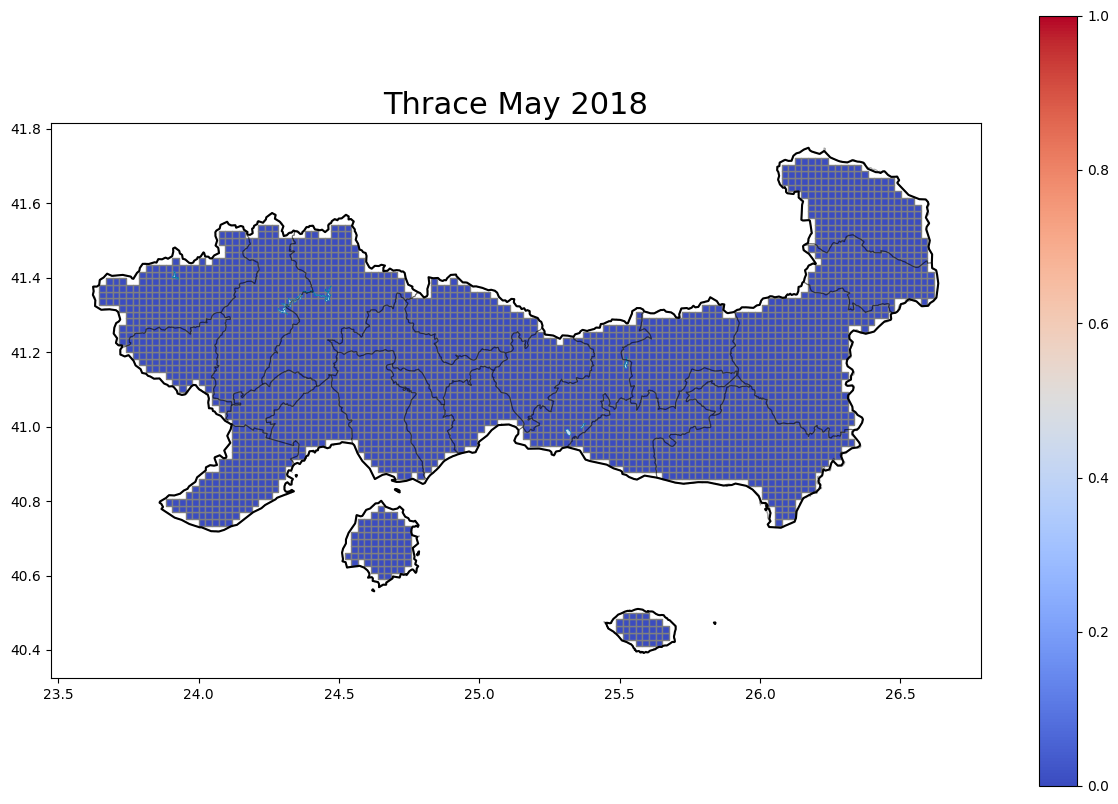

In [51]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} May {TEST_YEAR}', size = 22)
plt.show()

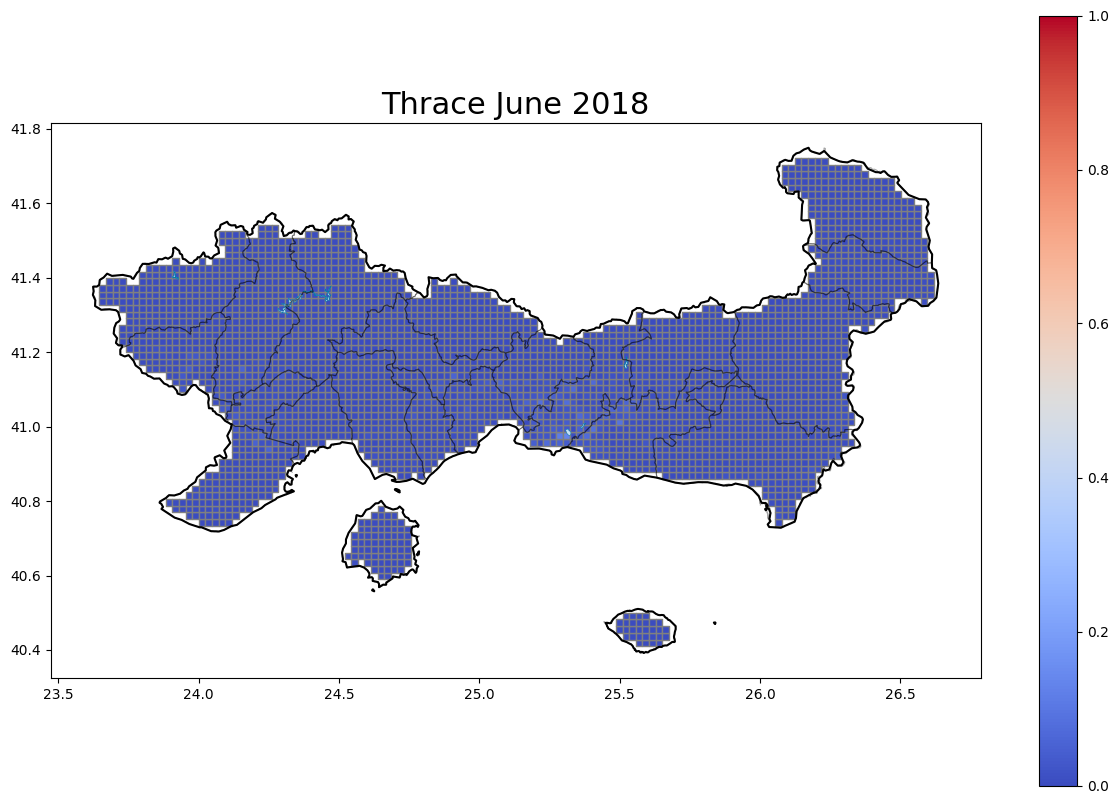

In [52]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} June {TEST_YEAR}', size = 22)
plt.show()

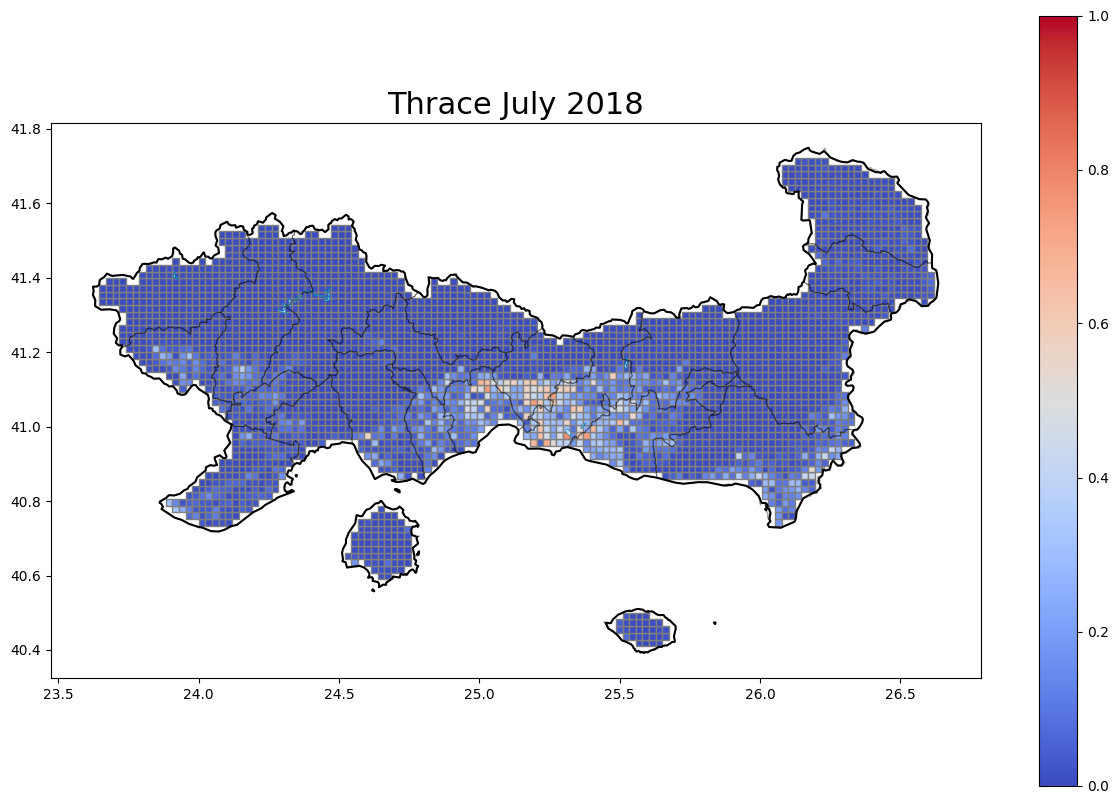

In [53]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} July {TEST_YEAR}', size = 22)
plt.show()

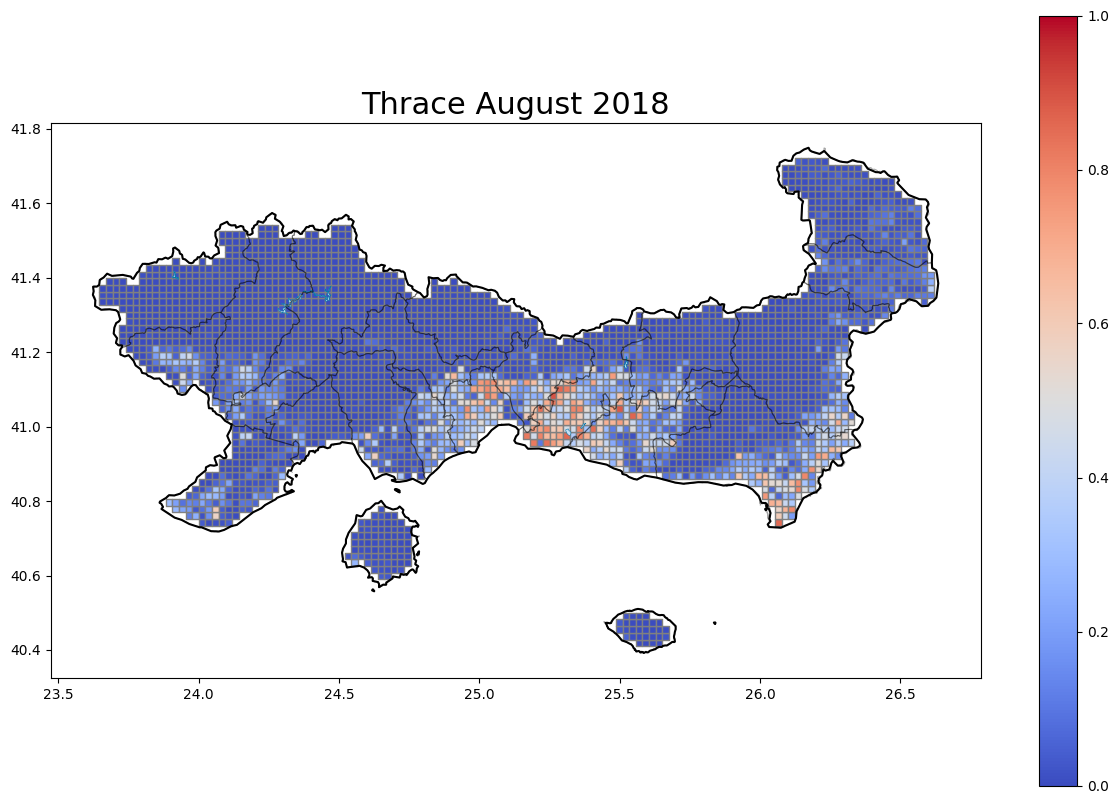

In [54]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} August {TEST_YEAR}', size = 22)
plt.show()

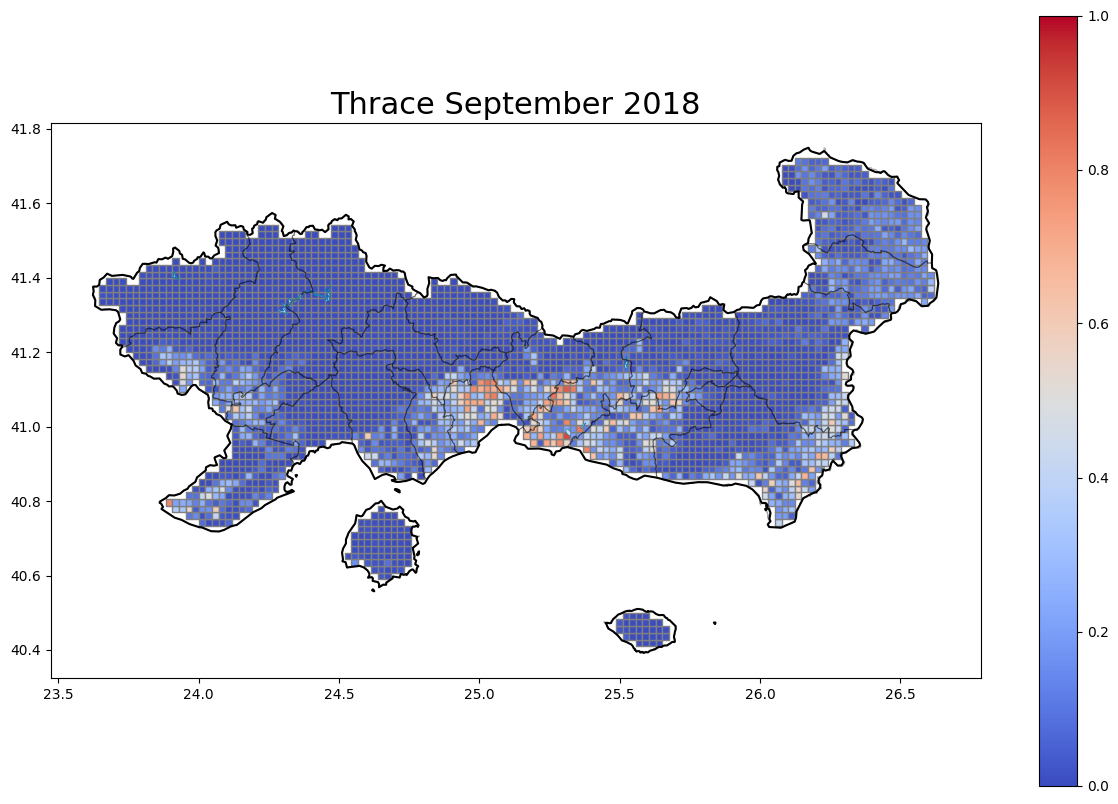

In [55]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} September {TEST_YEAR}', size = 22)
plt.show()

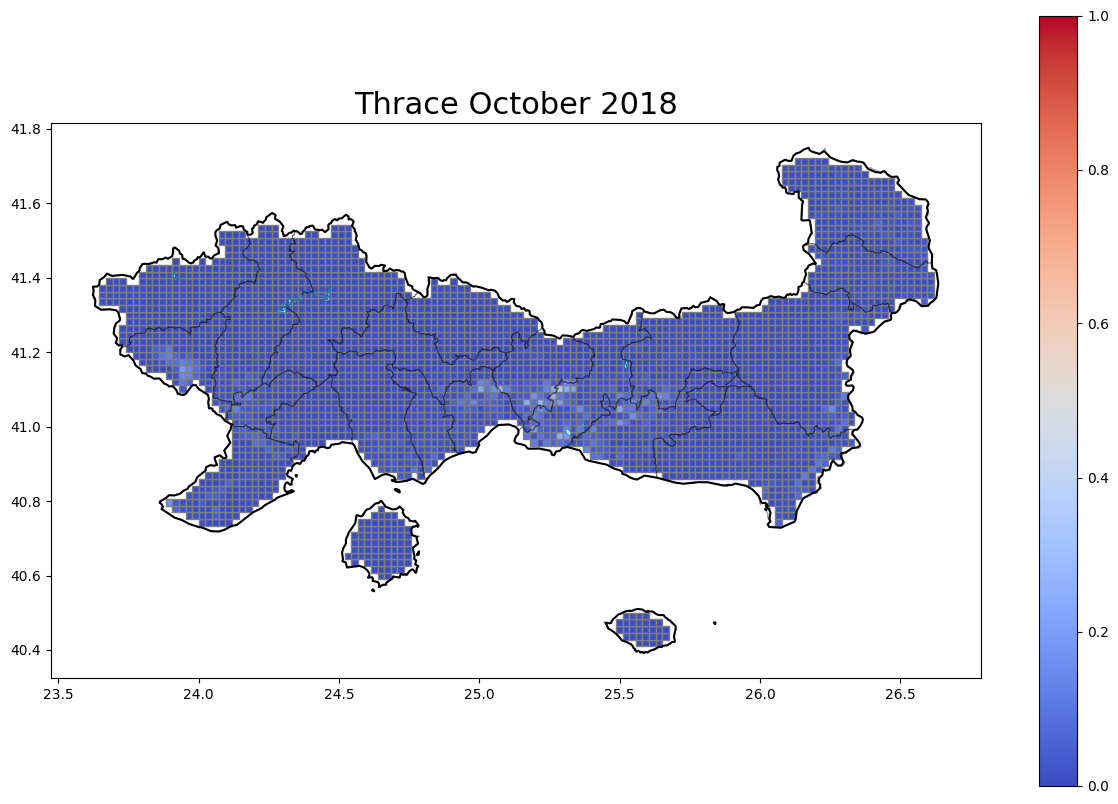

In [56]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'{NUTS2} October {TEST_YEAR}', size = 22)
plt.show()

In [57]:
greece_lakes['u_key'] = greece_lakes.index

In [58]:
results_aug['x'] = results_aug['x'].round(4)
results_aug['y'] = results_aug['y'].round(4)
results_aug['score'] = results_aug['score'].round(6)

In [59]:
results_aug.rename(columns={'score': 'risk_score'}, inplace=True)

In [60]:
cmap = plt.cm.coolwarm

# Convert Matplotlib colormap to Plotly colorscale
def matplotlib_to_plotly(cmap, pl_entries=255):
    h = 1.0/(pl_entries-1)
    pl_colorscale = []

    for k in range(pl_entries):
        C = list(map(np.uint8, np.array(cmap(k*h)[:3])*255))
        pl_colorscale.append([k*h, f'rgb{tuple(C)}'])

    return pl_colorscale

# Convert Matplotlib colormap to Plotly colorscale
coolwarm_colors = matplotlib_to_plotly(cmap)

In [61]:
import plotly.express as px
import plotly.graph_objects as go

gdf = results_aug
gdf2 = greece_lakes
gdf3 = greece_nuts2_gdf
gdf4 = greece_lau1

# Create an interactive plot with Plotly
fig = px.choropleth_mapbox(
    gdf,
    geojson=gdf.geometry.__geo_interface__,
    locations=gdf.cell_number,
    color="risk_score",
    hover_name="lau1",
    hover_data={"risk_score":True, "x": True, "y": True, "cell_number": False},
    mapbox_style="open-street-map",
    center={"lat": gdf.geometry.centroid.y.mean(), "lon": gdf.geometry.centroid.x.mean()},
    zoom=7.5,
    color_continuous_scale = coolwarm_colors,
    opacity=0.8,
    width=1200,  # Set the width of the figure
    height=800,  # Set the height of the figure
).update_layout(
    title={
        'text': f"{NUTS2} August {TEST_YEAR}",
        'x': 0.5,  # Adjust horizontal position (0 is left, 1 is right)
        'y': 0.97,  # Adjust vertical position (0 is bottom, 1 is top)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 30, 'color': 'black'},  # Adjust font size
    }
)

fig.add_trace(
    px.choropleth_mapbox(
        gdf2,
        geojson=gdf2.geometry.__geo_interface__,
        locations=gdf2.u_key,
        hover_name="name",
        hover_data={"u_key": False, "area":True, "length":True},
        color_discrete_sequence=['#aad3df'],  # Set a single color for all polygons in gdf2
        mapbox_style="open-street-map",
        opacity=1  # Adjust opacity to make the second layer translucent
    ).data[0]
).update_traces(showlegend=False)

for feature in gdf3.geometry:
    if feature.geom_type == 'Polygon':
        x, y = feature.exterior.xy
        fig.add_trace(go.Scattermapbox(
            mode='lines',
            lon=x.tolist(),
            lat=y.tolist(),
            line=dict(width=2, color='black'),
            hoverinfo='skip'  # Disable hover info for gdf2 boundaries
        )).update_traces(showlegend=False)

    elif feature.geom_type == 'MultiPolygon':
        for poly in feature.geoms:
            x,y = poly.exterior.xy
            fig.add_trace(go.Scattermapbox(
                mode='lines',
                lon=x.tolist(),
                lat=y.tolist(),
                line=dict(width=2, color='black'),
                hoverinfo='skip'  # Disable hover info for gdf2 boundaries
            )).update_traces(showlegend=False)

for feature in gdf4.geometry:
    if feature.geom_type == 'Polygon':
        x, y = feature.exterior.xy
        fig.add_trace(go.Scattermapbox(
            mode='lines',
            lon=x.tolist(),
            lat=y.tolist(),
            line=dict(width=0.8, color='black'),
            hoverinfo='skip'  # Disable hover info for gdf2 boundaries
        )).update_traces(showlegend=False)

    elif feature.geom_type == 'MultiPolygon':
        for poly in feature.geoms:
            x,y = poly.exterior.xy
            fig.add_trace(go.Scattermapbox(
                mode='lines',
                lon=x.tolist(),
                lat=y.tolist(),
                line=dict(width=0.8, color='black'),
                hoverinfo='skip'  # Disable hover info for gdf2 boundaries
            )).update_traces(showlegend=False)
        

# Show the plot
fig.show()

In [138]:
fig.write_html("test.html")

In [62]:
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")